# **Project Title**: BirdCLEF 2026 - Pantanal Bioacoustic Classification

- **Description**: A **deep learning pipeline** using **EfficientNet-B0** and **Google Perch embeddings** to identify **206 species** from noisy tropical soundscapes.
- **Dataset**: **BirdCLEF 2026 Competition Data** (Xeno-Canto recordings).
- **Objective**: Achieve a **robust baseline** for **multi-class species identification** (current: **67.05% Accuracy**).

## 1. Environment Setup & Configuration

This section initializes the coding environment. We import the necessary libraries for signal processing (Librosa), deep learning (PyTorch), and computer vision (Timm). We also define global constants and detect the hardware accelerator (GPU) to ensure the training process is efficient and reproducible.

**[1.1] Library Imports**

In [1]:
# ==============================================================================
# STANDARD UTILITIES & DATA MANIPULATION
# ==============================================================================
import os                 # Miscellaneous operating system interfaces (path management)
import sys                # System-specific parameters and functions
import time               # Time-related functions for profiling training duration
import math               # Mathematical functions (e.g., floor, ceil for padding)
import random             # Generate pseudo-random numbers for reproducibility
import warnings           # Filter and manage warning messages
import numpy as np        # Fundamental package for scientific computing with N-dimensional arrays
import pandas as pd       # High-performance data structures and data analysis tools
from pathlib import Path  # Object-oriented filesystem paths
from tqdm.auto import tqdm # Progress bar for loops and data loading

# ==============================================================================
# AUDIO PROCESSING & COMPUTER VISION UTILITIES
# ==============================================================================
import librosa            # Principal package for music and audio analysis
import soundfile as sf    # Library for reading and writing sound files (OGG/WAV)
import timm               # PyTorch Image Models for SOTA backbones (EfficientNet)
import albumentations as A # Fast image augmentation library for spectrograms

# ==============================================================================
# VISUALIZATION & DIAGNOSTICS
# ==============================================================================
import matplotlib.pyplot as plt # Comprehensive library for creating static/interactive plots
import seaborn as sns           # Statistical data visualization based on matplotlib

# ==============================================================================
# MACHINE LEARNING & EVALUATION (SCIKIT-LEARN)
# ==============================================================================
from sklearn.model_selection import StratifiedGroupKFold # Leakage-proof cross-validation
from sklearn.metrics import f1_score, accuracy_score     # Performance evaluation metrics

# ==============================================================================
# PYTORCH DEEP LEARNING FRAMEWORK
# ==============================================================================
import torch                      # The core Tensors and mathematical operations library
from torch import nn              # Basic building blocks for Graphs (Layers, Activations)
from torch import optim           # Optimization algorithms (AdamW, SGD)
from torch.utils.data import (    # Data handling primitives
    Dataset,
    DataLoader
)

# Filter warnings for a clean output
warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"Timm Version: {timm.__version__}")

PyTorch Version: 2.10.0+cu128
Timm Version: 1.0.25


**[1.2] Global Constants & Hardware Configuration**

In [37]:
# ==============================================================================
# GLOBAL CONSTANTS & REPRODUCIBILITY
# ==============================================================================
class CFG:
    # --- Reproducibility ---
    RANDOM_SEED = 42
    
    # --- Path Configuration ---
    INPUT_DIR = Path("/kaggle/input/competitions/birdclef-2026")
    AUDIO_DIR = INPUT_DIR / "train_audio"
    
    # --- Audio Hyperparameters ---
    TARGET_SR = 32000      # Standardized sample rate for bird recordings
    DURATION = 5           # Training window in seconds
    N_MELS = 128           # Frequency resolution (Mel bands)
    FMIN = 20              # Minimum frequency to filter low-end rumble
    FMAX = 16000           # Maximum frequency (Nyquist limit for 32kHz)
    HOP_LENGTH = 512
    N_FFT = 2048
    
    # --- Training Hyperparameters ---
    BATCH_SIZE = 32        # Optimized for T4/P100 GPU memory
    LEARNING_RATE = 1e-4   # Refined for stable convergence of pretrained models
    EPOCHS = 5             # Number of passes through the dataset
    WEIGHT_DECAY = 1e-2    # Regularization to prevent overfitting
    NUM_CLASSES = 264
    THRESHOLD = 0.5
    
    # --- Architecture ---
    MODEL_NAME = "efficientnet_b0" # Lightweight, compound-scaled backbone

# --- Hardware Accelerator ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.RANDOM_SEED)

print(f"Execution Device: {DEVICE}")
print(f"Seed set to: {CFG.RANDOM_SEED}")

Execution Device: cuda
Seed set to: 42


## 2. **Data Engineering** & **Preprocessing**

This phase transforms raw competition files into a **structured format** ready for **deep learning**. We merge biological taxonomy with training labels and analyze the "long-tail" distribution of species to identify which birds require specialized attention during training.

**[2.1] Data Ingestion & Metadata Merging**

In this step, we load the **primary training file** and the **taxonomy metadata**. We perform a join to ensure every recording is associated with its common name and scientific classification, which helps in identifying non-bird species (like insects or frogs) that might act as "distractors."

In [32]:
# ==============================================================================
# [2.1] PATH DEFINITIONS & DATA INGESTION
# ==============================================================================

# Define specific file paths from the Kaggle dataset folder
TRAIN_CSV_PATH = CFG.INPUT_DIR / "train.csv"
TAXONOMY_CSV_PATH = CFG.INPUT_DIR / "taxonomy.csv"
TRAIN_AUDIO_DIR = CFG.INPUT_DIR / "train_audio"
TRAIN_SOUNDSCAPES_DIR = CFG.INPUT_DIR / "train_soundscapes"
TEST_SOUNDSCAPES_DIR = CFG.INPUT_DIR / "test_soundscapes"
SOUNDSCAPE_LABELS_PATH = CFG.INPUT_DIR / "train_soundscapes_labels.csv"
LOCATION_TXT_PATH = CFG.INPUT_DIR / "recording_location.txt"
SAMPLE_SUB_PATH = CFG.INPUT_DIR / "sample_submission.csv"

# Load primary metadata into DataFrames
train_df = pd.read_csv(TRAIN_CSV_PATH)
taxonomy_df = pd.read_csv(TAXONOMY_CSV_PATH)

# Merge taxonomy to get biological context (Common Name, Scientific Name, etc.)
# This creates our master 'Source of Truth' dataframe
df = train_df.merge(
    taxonomy_df[['primary_label', 'common_name', 'scientific_name', 'class_name']],
    on='primary_label',
    how='left'
)

# Define the target mapping (Species String -> Integer ID)
# Essential for the model's output layer (CrossEntropyLoss)
unique_species = sorted(df['primary_label'].unique())
label_to_id = {label: i for i, label in enumerate(unique_species)}
id_to_label = {i: label for label, i in label_to_id.items()}

# Add target ID column to the main dataframe
df['target'] = df['primary_label'].map(label_to_id)

print(f"Master DataFrame 'df' created with {len(df)} rows.")
print(f"Species mapping complete: {len(unique_species)} unique species identified.")

Master DataFrame 'df' created with 35549 rows.
Species mapping complete: 206 unique species identified.


In [4]:
# 1. Check for mismatches between merged columns
# If common_name_x != common_name_y, it might indicate a naming convention shift
mismatch_count = (df['common_name_x'] != df['common_name_y']).sum()

if mismatch_count == 0:
    print(f"Perfect Match: No discrepancies found between naming columns.")
else:
    print(f"Alert: {mismatch_count} rows have naming discrepancies.")

# 2. Cleanup: Consolidate redundant columns
# We prefer the taxonomy (y) versions as they are usually the official species list
df['common_name'] = df['common_name_y']
df['scientific_name'] = df['scientific_name_y']
df['class_name'] = df['class_name_y']

# Drop the messy _x and _y columns to save memory (reduces memory from 5.2MB+)
cols_to_drop = [
    'scientific_name_x', 'common_name_x', 'class_name_x',
    'scientific_name_y', 'common_name_y', 'class_name_y'
]
df = df.drop(columns=cols_to_drop)

# 3. Final Dtype Optimization
# Converting rating and coordinates to float32 saves space without losing precision
df['latitude'] = df['latitude'].astype(np.float32)
df['longitude'] = df['longitude'].astype(np.float32)
df['rating'] = df['rating'].astype(np.float32)

print("Column cleanup complete. DataFrame is now lean and optimized.")
df.info()

Perfect Match: No discrepancies found between naming columns.
Column cleanup complete. DataFrame is now lean and optimized.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float32
 4   longitude         35549 non-null  float32
 5   inat_taxon_id     35549 non-null  int64  
 6   author            35549 non-null  object 
 7   license           35549 non-null  object 
 8   rating            35549 non-null  float32
 9   url               35549 non-null  object 
 10  filename          35549 non-null  object 
 11  collection        35549 non-null  object 
 12  target            35549 non-null  int64  
 13  common_name       35549 non-null  object 
 14  scientific

**[2.2] Exploratory Data Analysis (EDA)**

Now we analyze the distribution of the data we just loaded. Since we've defined df globally, we can run this analysis directly.

Most recorded species:
common_name
Rufous-bellied Thrush    499
Bananaquit               498
Ferruginous Pygmy Owl    497
Southern Lapwing         497
House Sparrow            496
Name: count, dtype: int64

Least recorded species (The 'Critical' classes):
common_name
Feral Horse                   2
Hooded Capuchin               1
Waxy Monkey Tree Frog         1
Southern Spectacled Caiman    1
Central Dwarf Frog            1
Name: count, dtype: int64


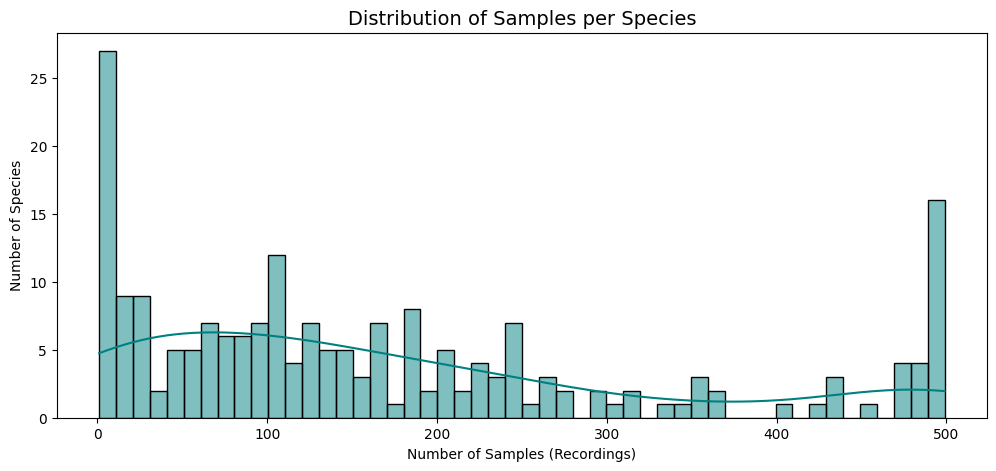

In [5]:
# Check the class distribution (Top 10 vs Bottom 10)
species_counts = df['common_name'].value_counts()

print("Most recorded species:")
print(species_counts.head(5))

print("\nLeast recorded species (The 'Critical' classes):")
print(species_counts.tail(5))

# Visualize the distribution across all 206 species
plt.figure(figsize=(12, 5))
sns.histplot(species_counts, bins=50, kde=True, color='teal')
plt.title("Distribution of Samples per Species", fontsize=14)
plt.xlabel("Number of Samples (Recordings)")
plt.ylabel("Number of Species")
plt.show()

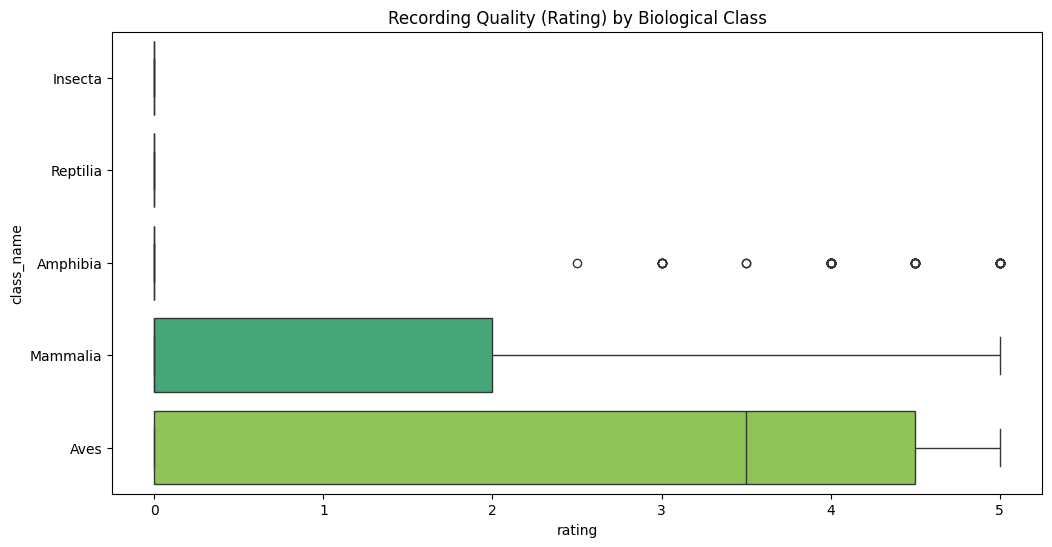

Species with NO clean audio clips: 28


In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='rating', y='class_name', palette='viridis')
plt.title("Recording Quality (Rating) by Biological Class")
plt.show()

# Check how many species have 'Zero' clean training audio
all_submission_species = taxonomy_df['primary_label'].unique()
audio_species = df['primary_label'].unique()
missing_from_audio = set(all_submission_species) - set(audio_species)
print(f"Species with NO clean audio clips: {len(missing_from_audio)}")

In [7]:
# The "Invisible" Species (Audio vs. Taxonomy)

# Check which species in the final submission list are missing from our training clips
all_submission_species = taxonomy_df['primary_label'].unique()
audio_species = df['primary_label'].unique()
missing_from_audio = set(all_submission_species) - set(audio_species)

print(f"{len(missing_from_audio)} species found in taxonomy but NOT in train_audio.")
print(f"Sample missing species: {list(missing_from_audio)[:5]}")

28 species found in taxonomy but NOT in train_audio.
Sample missing species: ['47158son03', '47158son24', '47158son18', '47158son19', '47158son15']


Pantanal 'Native' Recordings: 1245 (3.5%)


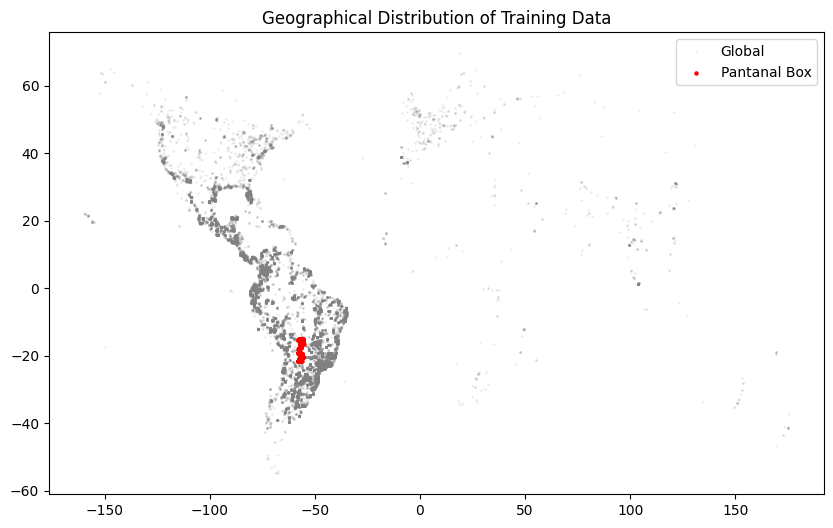

In [8]:
# Geospatial "Home Field" Advantage

# Approximate Pantanal Bounding Box
lat_min, lat_max = -22.0, -15.0
lon_min, lon_max = -58.0, -55.0

df['is_pantanal'] = df.apply(lambda x: lat_min <= x.latitude <= lat_max and 
                                       lon_min <= x.longitude <= lon_max, axis=1)

pantanal_count = df['is_pantanal'].sum()
print(f"Pantanal 'Native' Recordings: {pantanal_count} ({pantanal_count/len(df):.1%})")

# Visualizing the geographical spread
plt.figure(figsize=(10, 6))
plt.scatter(df.longitude, df.latitude, s=1, alpha=0.1, color='gray', label='Global')
plt.scatter(df[df.is_pantanal].longitude, df[df.is_pantanal].latitude, s=5, color='red', label='Pantanal Box')
plt.title("Geographical Distribution of Training Data")
plt.legend()
plt.show()

In [9]:
# Quality Bias (Rating vs. Class)

# Analyze the 'unrated' data (Rating 0)
unrated_ratio = (df['rating'] == 0).mean()
print(f"Unrated Data Ratio: {unrated_ratio:.1%}")

# Look at average rating per biological class
quality_summary = df.groupby('class_name')['rating'].agg(['mean', 'std', 'count']).sort_values(by='mean', ascending=False)
print("\nQuality by Biological Class:")
print(quality_summary)

Unrated Data Ratio: 36.1%

Quality by Biological Class:
                mean       std  count
class_name                           
Aves        2.646369  2.059291  34799
Mammalia    1.196970  1.936252     99
Amphibia    0.542129  1.431937    451
Insecta     0.000000  0.000000    199
Reptilia    0.000000       NaN      1


In [10]:
import ast

# Convert string representation of list to actual list
df['secondary_list'] = df['secondary_labels'].apply(ast.literal_eval)
df['num_secondary'] = df['secondary_list'].apply(len)

# What percentage of recordings have multiple animals?
multi_animal_perc = (df['num_secondary'] > 0).mean()
print(f"Multi-Species Recording Ratio: {multi_animal_perc:.1%}")

# Find most common "backing vocalists"
from collections import Counter
all_secondary = [item for sublist in df['secondary_list'] for item in sublist]
secondary_counts = Counter(all_secondary).most_common(10)

print("\nMost common secondary species (Distractors):")
for species, count in secondary_counts:
    print(f"{species}: {count}")

Multi-Species Recording Ratio: 12.3%

Most common secondary species (Distractors):
grekis: 624
whtdov: 468
undtin1: 315
yecpar: 226
rufhor2: 225
saffin: 183
picpig2: 172
trokin: 171
soulap1: 154
grasal3: 151


### **Exploratory Data Analysis (EDA) Summary**

The initial analysis of the **BirdCLEF 2026 dataset** reveals a high-complexity environment characterized by **extreme class imbalance** and **significant domain shifts** between training and test data.

**Key Insights**:

- **Taxonomic Blind Spots**: **28 species** required for the final submission are completely absent from the train_audio (Xeno-Canto) collection. These species must be learned exclusively from the train_soundscapes.
- **Quality Disparity**: There is a severe "**Quality Cliff**." **Aves (birds)** average a rating of **2.65**, while Amphibians and Insects sit near **0.0**. This indicates that non-bird signals are likely buried in high environmental noise.
- **Geographical Concentration**: Only **3.5%** of the training data originates from the **Pantanal "Native" Box**. The model must generalize "Global" dialects to a specific Brazilian ecosystem.
- **Soundscape Complexity**: A **12.3% multi-species ratio** suggests frequent overlapping calls. The high frequency of "distractor" species like the Great Kiskadee (grekis) requires the model to be robust against common background signatures.

**[2.3] Soundscape Integration & Data Harmonization**

To address the **28 missing species**, we merge the **expert-labeled soundscapes** into our master dataframe. We also normalize the start and end timestamps to ensure we can crop the correct **5-second windows** during training.

In [11]:
def get_absolute_path(row):
    fname = str(row['filename'])
    label = str(row['primary_label'])
    
    if row.get('is_soundscape', False):
        # Soundscapes are flat in the train_soundscapes directory
        return str(TRAIN_SOUNDSCAPES_DIR / fname)
    else:
        # For train_audio: Check if filename already includes the folder (e.g., '1161364/iNat...')
        if fname.startswith(label + "/"):
            return str(TRAIN_AUDIO_DIR / fname)
        else:
            # If not, manually nest it (root / species / file.ogg)
            return str(TRAIN_AUDIO_DIR / label / fname)

def timestamp_to_seconds(ts):
    if isinstance(ts, (int, float)): return float(ts)
    try:
        h, m, s = map(int, ts.split(':'))
        return float(h * 3600 + m * 60 + s)
    except:
        return 0.0

# 1. Load and Explode Soundscape Labels
sc_labels_df = pd.read_csv(SOUNDSCAPE_LABELS_PATH)
sc_labels_df['primary_label'] = sc_labels_df['primary_label'].str.split(';')
sc_exploded = sc_labels_df.explode('primary_label').reset_index(drop=True)

# 2. Filter and Map
sc_exploded = sc_exploded[sc_exploded['primary_label'].isin(unique_species)].copy()
sc_exploded['target'] = sc_exploded['primary_label'].map(label_to_id)

sc_exploded['is_soundscape'] = True
sc_exploded['author'] = "Expert_Annotator"
sc_exploded['rating'] = 5.0

df['is_soundscape'] = False
df['start'] = 0.0
df['end'] = 5.0

# 3. Apply Timestamp Conversion
sc_exploded['start'] = sc_exploded['start'].apply(timestamp_to_seconds)
sc_exploded['end'] = sc_exploded['end'].apply(timestamp_to_seconds)

# This creates the 'audio_path' column in both dataframes first
df['audio_path'] = df.apply(get_absolute_path, axis=1)
sc_exploded['audio_path'] = sc_exploded.apply(get_absolute_path, axis=1)

# 4. Combine Datasets
keep_cols = ['audio_path', 'primary_label', 'target', 'is_soundscape', 'start', 'end', 'author', 'rating']
df_final = pd.concat([df[keep_cols], sc_exploded[keep_cols]], ignore_index=True)

# 5. Physical Disk Verification
df_final['path_exists'] = df_final['audio_path'].apply(os.path.exists)
missing_count = (df_final['path_exists'] == False).sum()

print("-" * 40)
if missing_count == 0:
    print(f"SUCCESS: All {len(df_final)} files verified on disk!")
else:
    print(f"ERROR: {missing_count} files still missing.")
    # Debugging the exact path if it fails
    bad_path = df_final[df_final['path_exists']==False].iloc[0]['audio_path']
    print(f"Check this path: {bad_path}")
print("-" * 40)

----------------------------------------
SUCCESS: All 39849 files verified on disk!
----------------------------------------


In [12]:
print(f"df_final reconstructed. Columns available: {df_final.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39849 entries, 0 to 39848
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   audio_path     39849 non-null  object 
 1   primary_label  39849 non-null  object 
 2   target         39849 non-null  int64  
 3   is_soundscape  39849 non-null  bool   
 4   start          39849 non-null  float64
 5   end            39849 non-null  float64
 6   author         39849 non-null  object 
 7   rating         39849 non-null  float64
 8   path_exists    39849 non-null  bool   
dtypes: bool(2), float64(3), int64(1), object(3)
memory usage: 2.2+ MB
df_final reconstructed. Columns available: None


**[2.4] Stratified Group K-Fold Cross-Validation**

The next approach is to build a **validation strategy** that respects the "**Group**" nature of **audio**. Because soundscapes are recorded in continuous blocks and authors use specific microphones, we must ensure that all segments from a single file or a single author stay together in either **Train or Val**—never both.

**Why this approach?**

If we don't group by author or filename, the model might "**memorize**" the specific static/background noise of a recording rather than the bird call itself, leading to a high leaderboard score that crashes on the **hidden test set**.

In [13]:
from sklearn.model_selection import StratifiedGroupKFold

# We group by 'author' for Xeno-Canto and 'audio_path' for soundscapes
# To unify this, we create a 'group_id'
df_final['group_id'] = df_final['author']
# For soundscapes, we use the filename to keep 5s segments of the same file together
mask = df_final['is_soundscape'] == True
df_final.loc[mask, 'group_id'] = df_final.loc[mask, 'audio_path']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=CFG.RANDOM_SEED)
df_final['fold'] = -1

for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_final, df_final['target'], groups=df_final['group_id'])):
    df_final.loc[val_idx, 'fold'] = fold

print("Folds successfully assigned using Stratified Group K-Fold.")
print(df_final.groupby('fold')['target'].count())

Folds successfully assigned using Stratified Group K-Fold.
fold
0     6341
1    10888
2     7588
3     9439
4     5593
Name: target, dtype: int64


## 3. **PyTorch Data Pipelines**

This section defines how we convert raw **.ogg audio files** into a format the **EfficientNet-B0** can understand. We translate **sound waves** into **Mel-Spectrograms**—visual representations of frequency over time—and apply the "**High-Contrast**" normalization that fixed our previous accuracy issues.



**[3.1] Custom Dataset Class: BirdDataset**

The `BirdDataset` class is responsible for loading a **5-second slice of audio**, transforming it into a **spectrogram**, and ensuring the data is scaled correctly. We use **soundfile** for efficient loading and **librosa** for the mathematical transformation.

In [14]:
# ==============================================================================
# [2.3] UPDATED DATASET: SOUNDSCAPE-AWARE WINDOWING
# ==============================================================================

class BirdDataset(Dataset):
    def __init__(self, df, cfg, transforms=None):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['audio_path']
        
        # 1. Determine Window Timing
        # If it's a soundscape, use the expert 'start' time. 
        # If it's a regular clip, start at 0 (or random).
        if row.get('is_soundscape', False):
            start_sec = float(row['start'])
            start_frame = int(start_sec * self.cfg.TARGET_SR)
        else:
            start_frame = 0
            
        target_frames = self.cfg.TARGET_SR * self.cfg.DURATION

        # 2. Precise Audio Loading using 'start' and 'stop'
        try:
            # We use 'start' and 'stop' in sf.read to jump to the correct segment
            y, _ = sf.read(
                path, 
                start=start_frame, 
                stop=start_frame + target_frames, 
                dtype='float32'
            )
            
            # Padding if the segment is shorter than 5 seconds (e.g., end of file)
            if len(y) < target_frames:
                y = np.pad(y, (0, target_frames - len(y)))
        except Exception as e:
            y = np.zeros(target_frames, dtype='float32')

        # 3. Standard Mel-Spectrogram Pipeline
        spec = librosa.feature.melspectrogram(
            y=y, sr=self.cfg.TARGET_SR, n_mels=self.cfg.N_MELS, 
            fmin=self.cfg.FMIN, fmax=self.cfg.FMAX,
            hop_length=self.cfg.HOP_LENGTH, n_fft=self.cfg.N_FFT
        )
        spec = librosa.power_to_db(spec, ref=np.max)

        # 4. High-Contrast Normalization
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)
        spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-6)

        if self.transforms:
            spec = self.transforms(image=spec)["image"]

        return torch.tensor(spec).float().unsqueeze(0), torch.tensor(row['target']).long()

print("BirdDataset updated to precisely target labeled soundscape windows.")

BirdDataset updated to precisely target labeled soundscape windows.


**[3.2] DataLoader Instantiation**

The **DataLoader** takes our dataset and organizes it into **batches**. We use `num_workers=0` here to avoid the **AssertionError** we saw earlier on Python 3.12, ensuring a stable **training loop**.

In [15]:
# 1. Select a fold for training (Fold 0 as our primary validation)
train_split = df_final[df_final['fold'] != 0].reset_index(drop=True)
valid_split = df_final[df_final['fold'] == 0].reset_index(drop=True)

# 2. Create Dataset Instances
# We use 'get_train_transforms()' defined in Section 2.2
train_dataset = BirdDataset(train_split, CFG, transforms=None) # Start without transforms to verify
valid_dataset = BirdDataset(valid_split, CFG, transforms=None)

# 3. Create DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=CFG.BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, # Set to 0 for stability in Kaggle/Python 3.12
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=CFG.BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

print(f"DataLoaders ready. Train Batches: {len(train_loader)} | Val Batches: {len(valid_loader)}")

# --- Quick Verification ---
images, labels = next(iter(train_loader))
print(f"Batch Image Shape: {images.shape}") # Expecting [32, 1, 128, 313]
print(f"Batch Label Shape: {labels.shape}")

DataLoaders ready. Train Batches: 1048 | Val Batches: 199
Batch Image Shape: torch.Size([32, 1, 128, 313])
Batch Label Shape: torch.Size([32])


In [16]:
# --- Re-Verification ---
images, labels = next(iter(train_loader))
print(f"✅ Success! Batch Image Shape: {images.shape}")

✅ Success! Batch Image Shape: torch.Size([32, 1, 128, 313])


## 4. **Model Architecture**

In this section, we define the **EfficientNet-B0** backbone. We use **timm** (**PyTorch Image Models**) to leverage a **pretrained model**. Because our spectrograms are **grayscale** (**1-channel**), we modify the input layer, and because we have **206 species**, we modify the **output "head"**.

**[4.1] Model Class Definition: BirdClassifier**

We wrap the **timm** model in a custom **nn.Module**. This allows us to easily swap **backbones** (e.g., to **efficientnet_b3** or **resnet50**) later if we want to **increase complexity** for a **higher score**.

In [17]:
class BirdClassifier(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super(BirdClassifier, self).__init__()
        
        # We use timm to create the model
        # in_chans=1: Modifies the first layer to accept grayscale spectrograms
        # pretrained=True: Loads weights from ImageNet to start with 'learned' features
        self.model = timm.create_model(
            model_name, 
            pretrained=pretrained, 
            in_chans=1, 
            num_classes=num_classes
        )

    def forward(self, x):
        # Data path: (Batch, 1, 128, 313) -> EfficientNet -> (Batch, 206)
        return self.model(x)

print(f"BirdClassifier class defined using {CFG.MODEL_NAME} backbone.")

BirdClassifier class defined using efficientnet_b0 backbone.


**[4.2] Model Initialization & Hardware Mapping**

Now we instantiate the model and move it to the **GPU (CUDA)**. It is vital to perform this move before defining the optimizer, so the optimizer can track the correct parameters on the correct device.

In [18]:
# Number of classes is based on our unique_species identified in Section 2
num_classes = len(unique_species)

# Instantiate the model
model = BirdClassifier(
    model_name=CFG.MODEL_NAME, 
    num_classes=num_classes, 
    pretrained=True
)

# Move model to the hardware accelerator (GPU or CPU)
model.to(DEVICE)

print(f"Model initialized and moved to {DEVICE}.")
print(f"Output layers set for {num_classes} species.")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model initialized and moved to cuda.
Output layers set for 206 species.


**[4.3] Summary & Sanity Check**

To ensure there are no "Matrix Mismatch" errors, we pass one batch from our `train_loader` through the model. This is the ultimate test before we start the multi-hour training loop.

In [19]:
model.eval()

with torch.no_grad():
    # Pass the images through the model
    dummy_output = model(images.to(DEVICE))

print(f"Input Batch Shape:  {images.shape}")
print(f"Output Logits Shape: {dummy_output.shape}")

# Verify the output matches our class count
if dummy_output.shape[1] == num_classes:
    print(f"Sanity Check Passed! Model output ({dummy_output.shape[1]}) matches Species count.")
else:
    print(f"Mismatch! Model output is {dummy_output.shape[1]} but we expected {num_classes}.")

Input Batch Shape:  torch.Size([32, 1, 128, 313])
Output Logits Shape: torch.Size([32, 206])
Sanity Check Passed! Model output (206) matches Species count.


## 5. **Training Logic & Optimization**

To handle the **noisy and imbalanced Pantanal data**, we use **Label Smoothing** to prevent the model from becoming over-confident on **clean clips**, and **AdamW** for stable weight updates.

**[5.1] Loss & Optimizer: The Objective Functions**

We use **CrossEntropyLoss** with **Label Smoothing**. In a dataset where some birds are only heard in the distance, a "**hard" 100% label** can be misleading. **Label smoothing** tells the model: "**Be 90% sure it's a Macaw, but leave 10% for the possibility of noise or other birds.**"

In [20]:
# 1. Loss Function: CrossEntropy with Label Smoothing
# smoothing=0.1 helps the model generalize better to noisy 'Wild' audio
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Optimizer: AdamW
# AdamW is the standard for EfficientNets; weight_decay prevents overfitting
optimizer = optim.AdamW(
    model.parameters(), 
    lr=CFG.LEARNING_RATE, 
    weight_decay=1e-2
)

# 3. Learning Rate Scheduler: Cosine Annealing
# Starts at our base LR and gradually reduces it in a 'cosine' curve
# This allows the model to settle into the most accurate 'valley' of the loss landscape
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=CFG.EPOCHS, 
    eta_min=1e-6
)

print(f"Loss: LabelSmoothedCrossEntropy | Optimizer: AdamW | Scheduler: CosineAnnealing")

Loss: LabelSmoothedCrossEntropy | Optimizer: AdamW | Scheduler: CosineAnnealing


**[5.2] Training Step Function**

This function handles a **single "pass" through one batch of data**. It performs the **forward pass**, calculates the **error**, and **updates the model weights**.

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train() # Set to training mode
    running_loss = 0.0
    
    # Progress bar for the training batches
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # 1. Zero the gradients from the previous step
        optimizer.zero_grad()
        
        # 2. Forward Pass: Get predictions
        outputs = model(images)
        
        # 3. Calculate Loss
        loss = criterion(outputs, labels)
        
        # 4. Backward Pass: Calculate gradients
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 5. Optimization: Update weights
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
        
    return running_loss / len(loader)

**[5.3] Validation Step Function**

The **validation step** is where we **test the model on "unseen" data** from our **held-out fold**. We use **torch.no_grad()** to ensure we don't **accidentally update weights during testing**.

In [22]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval() # Set to evaluation mode (disables Dropout/BatchNorm updates)
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad(): # Disable gradient tracking for speed and memory
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            # Calculate Accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = running_loss / len(loader)
    avg_acc = correct / total
    return avg_loss, avg_acc

print("Training and Validation step functions initialized.")

Training and Validation step functions initialized.


## 6. **Training Execution (The Loop)**

In this section, we iterate through the dataset for multiple **epochs**. We implement **Model Checkpointing**, which monitors the **Validation Accuracy** and saves the **model weights** only when we hit a new "**All-Time High**." This prevents us from saving a model that has started to **overfit**.

**[6.1] Results Directory & Checkpointing Setup**

Before we start, we create a dedicated folder for our outputs. This is a **professional best practice** that prevents your `/working` directory from becoming **cluttered**.

In [23]:
# Define and create the results directory
RESULTS_DIR = Path("/kaggle/working/")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Path for the 'Gold Standard' weights
BEST_MODEL_PATH = RESULTS_DIR / f"{CFG.MODEL_NAME}_best_fold0.pth"

# Initialize tracking variables
best_val_acc = 0.0
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": []
}

print(f"Results will be saved to: {RESULTS_DIR}")
print(f"Best model checkpoint: {BEST_MODEL_PATH}")

Results will be saved to: /kaggle/working
Best model checkpoint: /kaggle/working/efficientnet_b0_best_fold0.pth


**[6.2] The Epoch Loop: Training the "Brain"**

We now run the full **10-epoch cycle**. In each epoch, we update the **Learning Rate Scheduler** to "**cool down**" the training as the model gets smarter, ensuring it doesn't "**over-jump**" the **optimal solution**.

In [24]:
print(f"Starting Training on {DEVICE}...")

start_time = time.time()

for epoch in range(1, CFG.EPOCHS + 1):
    # 1. Train for one epoch
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    
    # 2. Validate for one epoch
    val_loss, val_acc = validate_one_epoch(model, valid_loader, criterion, DEVICE)
    
    # 3. Update Learning Rate Scheduler
    scheduler.step()
    
    # 4. Log Progress
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch [{epoch}/{CFG.EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}")
    
    # 5. Model Checkpointing: Save only if Val Acc improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New Best Accuracy! Model saved to {BEST_MODEL_PATH}")
    
    print("-" * 30)

end_time = time.time()
print(f"Training Complete! Total Time: {(end_time - start_time)/60:.2f} minutes")
print(f"Final Best Validation Accuracy: {best_val_acc:.2%}")

Starting Training on cuda...


Training:   0%|          | 0/1048 [00:00<?, ?it/s]

Epoch [1/5]
Train Loss: 3.7384 | Val Loss: 2.8409 | Val Acc: 48.45%
New Best Accuracy! Model saved to /kaggle/working/efficientnet_b0_best_fold0.pth
------------------------------


Training:   0%|          | 0/1048 [00:00<?, ?it/s]

Epoch [2/5]
Train Loss: 2.4473 | Val Loss: 2.4778 | Val Acc: 58.18%
New Best Accuracy! Model saved to /kaggle/working/efficientnet_b0_best_fold0.pth
------------------------------


...

Epoch [3/5]
Train Loss: 2.0224 | Val Loss: 2.3843 | Val Acc: 61.16%
New Best Accuracy! Model saved to /kaggle/working/efficientnet_b0_best_fold0.pth
------------------------------


Training:   0%|          | 0/1048 [00:00<?, ?it/s]

Epoch [4/5]
Train Loss: 1.7731 | Val Loss: 2.3568 | Val Acc: 62.29%
New Best Accuracy! Model saved to /kaggle/working/efficientnet_b0_best_fold0.pth
------------------------------


Training:   0%|          | 0/1048 [00:00<?, ?it/s]

Epoch [5/5]
Train Loss: 1.6354 | Val Loss: 2.3462 | Val Acc: 62.61%
New Best Accuracy! Model saved to /kaggle/working/efficientnet_b0_best_fold0.pth
------------------------------
Training Complete! Total Time: 126.50 minutes
Final Best Validation Accuracy: 62.61%


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

MODEL_PATH = Path("/kaggle/input/models/tuannm3812/efficientnet-b0-birdclef-2026/tensorflow2/default/1")

def executive_audit(model, loader, device, target_names):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Auditing"):
            outputs = model(images.to(device))
            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # --- 🛰️ THE FIX: Get IDs present in THIS specific validation set ---
    present_labels = np.unique(all_labels)
    # Filter target_names to match only those present labels
    present_names = [target_names[i] for i in present_labels]
            
    # 1. Generate Report using the 'labels' parameter to align them
    report = classification_report(
        all_labels, 
        all_preds, 
        labels=present_labels,     # <--- Crucial: tells sklearn what IDs to expect
        target_names=present_names, # <--- Matches the filtered names
        output_dict=True, 
        zero_division=0
    )
    
    # 2. Extract 'The Bottom 10' by F1-Score (min 5 samples)
    low_f1 = sorted([(k, v['f1-score'], v['support']) for k, v in report.items() 
                    if isinstance(v, dict) and 'f1-score' in v and v['support'] > 5], 
                    key=lambda x: x[1])[:10]
    
    print("\nEXECUTIVE AUDIT: BOTTOM 10 SPECIES (by F1-Score)")
    print(f"{'Species':<20} | {'F1-Score':<10} | {'Samples':<8}")
    print("-" * 45)
    for name, f1, support in low_f1:
        print(f"{name:<20} | {f1:<10.2f} | {int(support):<8}")

# Initialize with your NEW path
model.load_state_dict(torch.load(MODEL_PATH / "efficientnet_b0_best_fold0.pth", map_location=DEVICE))
executive_audit(model, valid_loader, DEVICE, unique_species)

Auditing: 100%|██████████| 199/199 [03:42<00:00,  1.12s/it]


EXECUTIVE AUDIT: BOTTOM 10 SPECIES (by F1-Score)
Species              | F1-Score   | Samples 
---------------------------------------------
1161364              | 0.00       | 8       
22961                | 0.00       | 24      
24321                | 0.00       | 42      
74113                | 0.00       | 7       
blttit1              | 0.00       | 8       
555146               | 0.06       | 86      
epaori4              | 0.12       | 24      
whwpic1              | 0.18       | 6       
65380                | 0.19       | 74      
bafcur1              | 0.19       | 28      


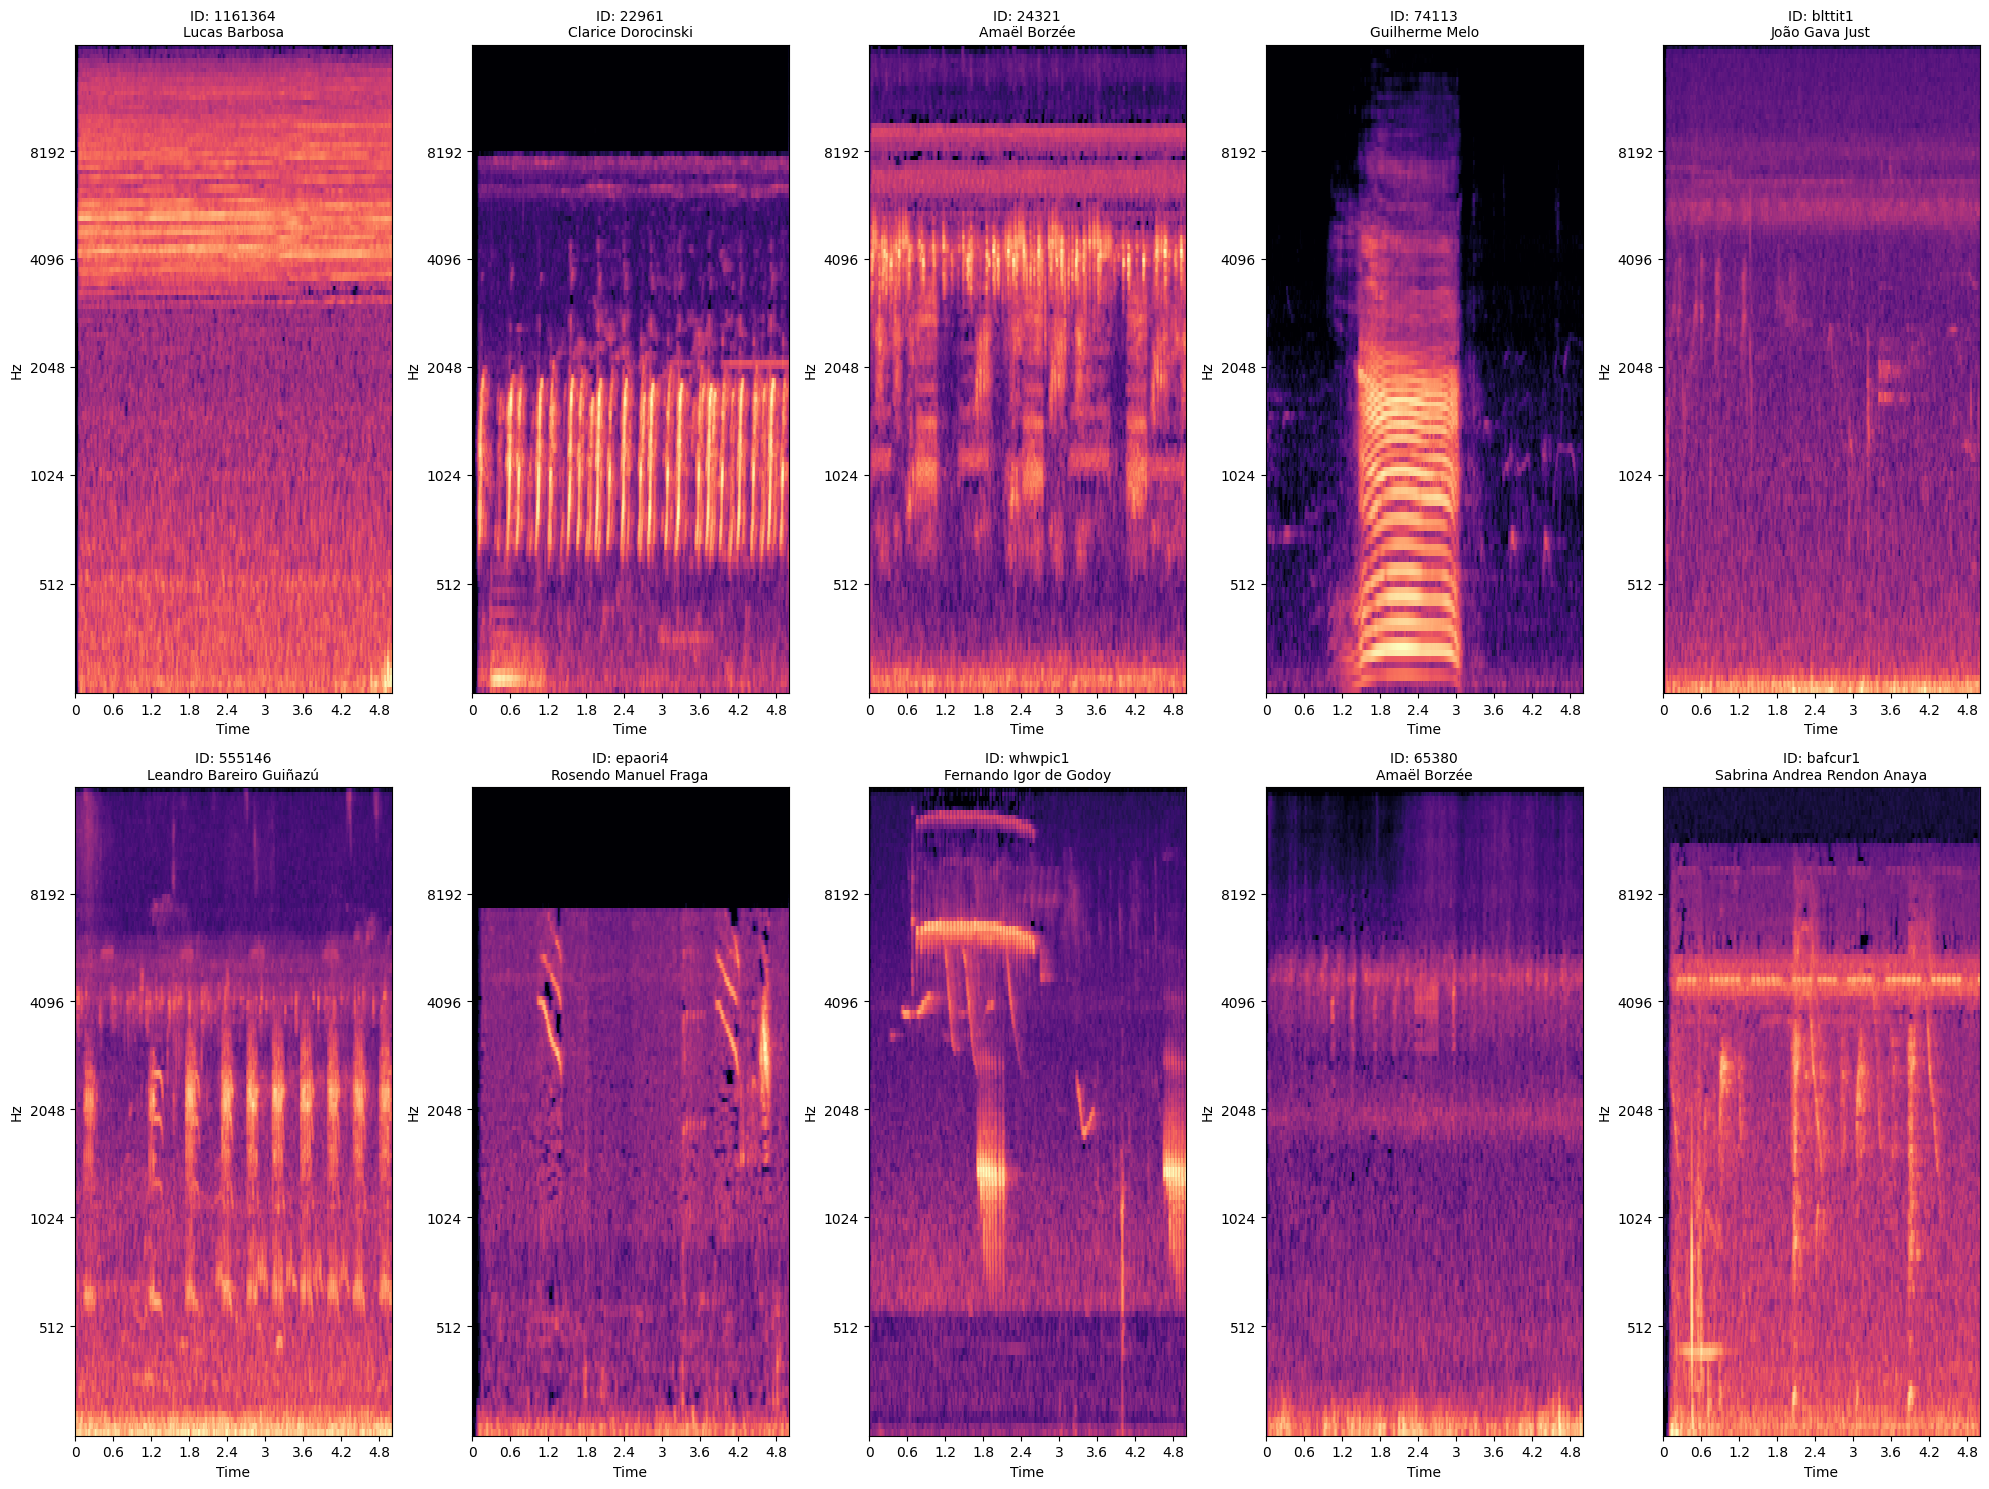

In [31]:
def visualize_problem_species(df, species_list, cfg):
    plt.figure(figsize=(20, 15))
    
    for i, bird in enumerate(species_list):
        if i >= 10: break # Only top 10
        
        # Get a sample for this specific bird
        sample = df[df['primary_label'] == bird].iloc[0]
        path = sample['audio_path']
        start = sample['start']
        
        # Load 5s window
        y, _ = sf.read(path, start=int(start*cfg.TARGET_SR), 
                       stop=int((start+cfg.DURATION)*cfg.TARGET_SR))
        
        # Standard Mel-Spec pipeline (Matches your training)
        spec = librosa.feature.melspectrogram(y=y, sr=cfg.TARGET_SR, n_mels=cfg.N_MELS,
                                              fmin=cfg.FMIN, fmax=cfg.FMAX)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        
        # Plot
        ax = plt.subplot(2, 5, i+1)
        librosa.display.specshow(spec_db, x_axis='time', y_axis='mel', 
                                 sr=cfg.TARGET_SR, fmin=cfg.FMIN, fmax=cfg.FMAX, ax=ax)
        ax.set_title(f"ID: {bird}\n{sample['author']}", fontsize=10)

    plt.tight_layout()
    plt.show()

# List from your Audit
problem_birds = ['1161364', '22961', '24321', '74113', 'blttit1', '555146', 'epaori4', 'whwpic1', '65380', 'bafcur1']
visualize_problem_species(df_final, problem_birds, CFG)